# Clean Data for Proof of Concept

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../")

from src.config import start_date, end_date, relevant_option_columns

In [2]:
path_base = '../data/options/data/Options/'
option_data_gs = pd.read_csv(path_base + 'Financials/options_GS.csv')
metadata_options = pd.read_csv(path_base + 'options-data-dictionary.csv')

init_shape = option_data_gs.shape
init_size = option_data_gs.size
print(f"Initial shape: {init_shape}")
print(f"Initial size: {init_size}")

/var/folders/3t/5vvh8l5x48s7tyvbx4b6v9xr0000gn/T/ipykernel_34552/879504262.py:2: DtypeWarning: Columns (23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  option_data_gs = pd.read_csv(path_base + 'Financials/options_GS.csv')


Initial shape: (5192639, 38)
Initial size: 197320282


## Remove all columns we don't need

In [3]:
option_data_gs = option_data_gs[relevant_option_columns]

## Only Consider Data in a Certain Range

In [4]:
option_data_gs = option_data_gs[(option_data_gs["date"] >= start_date) & (option_data_gs["date"] <= end_date)]

In [8]:
final_shape = option_data_gs.shape
final_size = option_data_gs.size

print(f"Final shape: {final_shape}")
print(f"Final size: {final_size}")
print(f"Removed {(1-final_size/init_size)*100:.2f}% of the data")

Final shape: (1353148, 19)
Final size: 25709812
Removed 86.97% of the data


In [18]:
option_data_gs.isna().any(axis=1).sum()


456487

In [9]:
option_data_gs.isna().sum()

secid                   0
date                    0
symbol                  0
symbol_flag             0
exdate                  0
last_date          380064
cp_flag                 0
strike_price            0
best_bid                0
best_offer              0
volume                  0
open_interest           0
impl_volatility    171505
delta              171505
gamma              171505
vega               171505
theta              171505
optionid                0
contract_size           0
dtype: int64

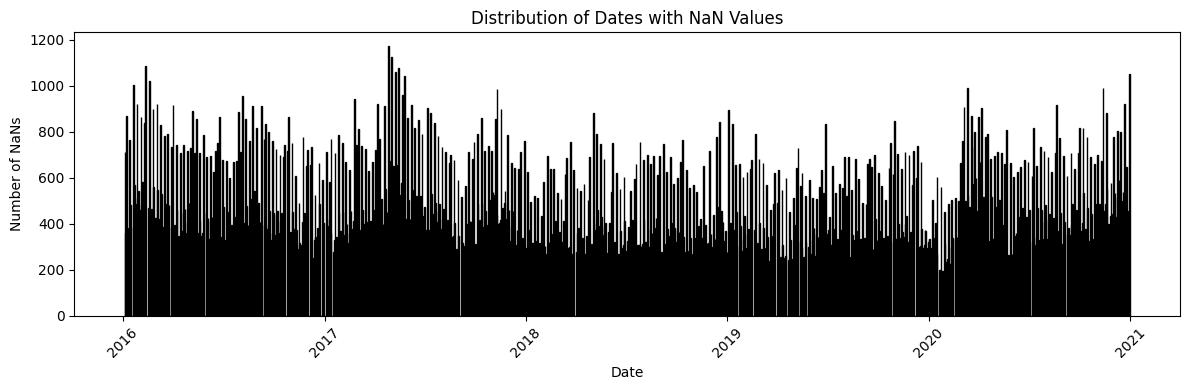

In [13]:
import matplotlib.pyplot as plt

# Get dates where any NaN appears in the row
nan_dates = option_data_gs.loc[option_data_gs.isna().any(axis=1), "date"]

# Convert to datetime if not already
nan_dates = pd.to_datetime(nan_dates)

plt.figure(figsize=(12, 4))
plt.hist(nan_dates, bins=len(nan_dates.unique()), color='orange', edgecolor='k')
plt.title('Distribution of Dates with NaN Values')
plt.xlabel('Date')
plt.ylabel('Number of NaNs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
nan_rows = option_data_gs[option_data_gs.isna().any(axis=1)]
nan_rows.head()

,secid,date,symbol,symbol_flag,exdate,last_date,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,contract_size
1270507,105329,2016-01-04,GS 160108C125000,1,2016-01-08,NaN,C,125000,49.80,53.70,0,0,NaN,NaN,NaN,NaN,NaN,110310858,100
1270508,105329,2016-01-04,GS 160108C130000,1,2016-01-08,NaN,C,130000,44.80,48.60,0,0,NaN,NaN,NaN,NaN,NaN,110310859,100
1270509,105329,2016-01-04,GS 160108C135000,1,2016-01-08,NaN,C,135000,39.55,42.50,0,0,NaN,NaN,NaN,NaN,NaN,110310860,100
1270510,105329,2016-01-04,GS 160108C140000,1,2016-01-08,NaN,C,140000,34.45,37.50,0,0,NaN,NaN,NaN,NaN,NaN,110310861,100
1270511,105329,2016-01-04,GS 160108C145000,1,2016-01-08,NaN,C,145000,29.65,33.55,0,0,NaN,NaN,NaN,NaN,NaN,110310862,100


In [17]:
last_date_nan_df = option_data_gs.loc[(option_data_gs["last_date"].isna()), :]
last_date_nan_df.describe()


,secid,symbol_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility,delta,gamma,vega,theta,optionid,contract_size
count,380064.0,380064.0,380064.000000,380064.000000,380064.000000,380064.0,380064.000000,284982.000000,284982.000000,284982.000000,284982.000000,284982.000000,3.800640e+05,380064.0
mean,105329.0,1.0,212354.642902,40.586150,42.666167,0.0,0.000168,0.511838,0.069261,0.005046,12.551691,-19.980934,1.219517e+08,100.0
std,0.0,0.0,69621.831416,36.772201,37.734005,0.0,0.025544,0.481558,0.750835,0.005782,20.290078,46.067994,8.724144e+06,0.0
min,105329.0,1.0,70000.000000,0.000000,0.010000,0.0,0.000000,0.017530,-0.999987,0.000000,0.000440,-1346.296000,1.022152e+08,100.0
25%,105329.0,1.0,152500.000000,8.650000,9.700000,0.0,0.000000,0.267216,-0.811770,0.001170,1.621424,-20.975440,1.143214e+08,100.0
50%,105329.0,1.0,210000.000000,32.600000,34.950000,0.0,0.000000,0.363144,0.006174,0.002922,5.155134,-9.383914,1.192531e+08,100.0
75%,105329.0,1.0,270000.000000,64.400000,67.400000,0.0,0.000000,0.560875,0.920056,0.006560,14.148428,-3.940512,1.303336e+08,100.0
max,105329.0,1.0,410000.000000,251.300000,255.400000,0.0,5.000000,8.814270,1.000000,0.096397,144.335700,10.813000,1.377807e+08,100.0


## Ensure Correct Data Types

In [19]:
option_data_gs.dtypes

secid                int64
date                object
symbol              object
symbol_flag          int64
exdate              object
last_date           object
cp_flag             object
strike_price         int64
best_bid           float64
best_offer         float64
volume               int64
open_interest        int64
impl_volatility    float64
delta              float64
gamma              float64
vega               float64
theta              float64
optionid             int64
contract_size        int64
dtype: object

In [20]:
option_data_gs['date'] = pd.to_datetime(option_data_gs['date'])
option_data_gs['exdate'] = pd.to_datetime(option_data_gs['exdate'])
option_data_gs['last_date'] = pd.to_datetime(option_data_gs['last_date'])

option_data_gs.dtypes

secid                       int64
date               datetime64[ns]
symbol                     object
symbol_flag                 int64
exdate             datetime64[ns]
last_date          datetime64[ns]
cp_flag                    object
strike_price                int64
best_bid                  float64
best_offer                float64
volume                      int64
open_interest               int64
impl_volatility           float64
delta                     float64
gamma                     float64
vega                      float64
theta                     float64
optionid                    int64
contract_size               int64
dtype: object

## Add Time to Expiration (tte)

In [26]:
option_data_gs['tte_years'] = (option_data_gs['exdate'] - option_data_gs['date']).dt.days / 365.0
option_data_gs['tte_days'] = (option_data_gs['exdate'] - option_data_gs['date']).dt.days

In [27]:
option_data_gs.dtypes

secid                       int64
date               datetime64[ns]
symbol                     object
symbol_flag                 int64
exdate             datetime64[ns]
last_date          datetime64[ns]
cp_flag                    object
strike_price                int64
best_bid                  float64
best_offer                float64
volume                      int64
open_interest               int64
impl_volatility           float64
delta                     float64
gamma                     float64
vega                      float64
theta                     float64
optionid                    int64
contract_size               int64
ttl                       float64
tte_years                 float64
tte_days                    int64
dtype: object